In [241]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import pypsa
import yaml

### Scenario selection

In [242]:
PREFIX = "/mnt/c/Users/scl38887/Documents/git/pypsa-nz/"

In [243]:
OUTPUT = PREFIX + "results/figures/sensitivity/"

In [244]:
results = "results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens"

scenarios = {
            "-50_ely": PREFIX + results + "-50_techelectrolyzer_cost.nc",
            "-30_ely": PREFIX + results + "-30_techelectrolyzer_cost.nc",
            "0_ely": PREFIX + results + "0_techelectrolyzer_cost.nc",
            "30_ely": PREFIX + results + "30_techelectrolyzer_cost.nc",
            "50_ely": PREFIX + results + "50_techelectrolyzer_cost.nc",

            "-50_offshore": PREFIX + results + "-50_techoffshore_cost.nc",
            "-30_offshore": PREFIX + results + "-30_techoffshore_cost.nc",
            "0_offshore": PREFIX + results + "0_techoffshore_cost.nc",
            "30_offshore": PREFIX + results + "30_techoffshore_cost.nc",
            "50_offshore": PREFIX + results + "50_techoffshore_cost.nc",

            "-50_tank": PREFIX + results + "-50_techstorage_tank_cost.nc",
            "-30_tank": PREFIX + results + "-30_techstorage_tank_cost.nc",
            "0_tank": PREFIX + results + "0_techstorage_tank_cost.nc",
            "30_tank": PREFIX + results + "30_techstorage_tank_cost.nc",
            "50_tank": PREFIX + results + "50_techstorage_tank_cost.nc",
            }

In [245]:
scenarios

{'-50_ely': '/mnt/c/Users/scl38887/Documents/git/pypsa-nz/results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens-50_techelectrolyzer_cost.nc',
 '-30_ely': '/mnt/c/Users/scl38887/Documents/git/pypsa-nz/results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens-30_techelectrolyzer_cost.nc',
 '0_ely': '/mnt/c/Users/scl38887/Documents/git/pypsa-nz/results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens0_techelectrolyzer_cost.nc',
 '30_ely': '/mnt/c/Users/scl38887/Documents/git/pypsa-nz/results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens30_techelectrolyzer_cost.nc',
 '50_ely': '/mnt/c/Users/scl38887/Documents/git/pypsa-nz/results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens50_techelectrolyzer_cost.nc',
 '-50_offshor

In [246]:
# scenarios = {
#             "-50": PREFIX + f"results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens-50.nc",
#             "0": PREFIX + f"results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens0.nc",
#             "30": PREFIX + f"results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens30.nc",
#             "50": PREFIX + f"results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens50.nc",
#             }

In [247]:
tech_colors = PREFIX + "config/tech_colors.yaml"

In [248]:
threshold_dispatch = 1e6 # TWh

### Validation

In [249]:
# Compare the network solved using the sensitivity workflow vs the regular workflow

n_regular = pypsa.Network(PREFIX + "results/nz_2035_lowfix_lowcagr/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export.nc")

n_sens0 = pypsa.Network(PREFIX + "results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens0.nc")

n_sens30 = pypsa.Network(PREFIX + "results/nz_2035_lowfix_lowcagr/sensitivity/postnetworks/elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens30.nc")

Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens0.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['H2 pipeline NZ.15_1 -> NZ.

#### Cost difference electrolyzer

In [250]:
ely_cost_regular = n_regular.links[n_regular.links.carrier == "H2 Electrolysis"].capital_cost.mean()

In [251]:
ely_cost_sens30 = n_sens30.links[n_sens30.links.carrier == "H2 Electrolysis"].capital_cost.mean()

In [252]:
print(f"The cost difference between the regular and sensitivity (30) networks is ", ((ely_cost_sens30 - ely_cost_regular) / ely_cost_regular) * 100, "%")

The cost difference between the regular and sensitivity (30) networks is  29.999999999999975 %


#### Objective value

In [253]:
n_regular.objective / 1e6, n_sens0.objective / 1e6, n_sens30.objective / 1e6

(7014.961300759552, 7017.463284322601, 7043.016160772995)

#### Hydrogen price

In [254]:
# get_weighted_hydrogen_price(n_regular)

In [255]:
# get_weighted_hydrogen_price(n_sens0)

#### Dispatch

In [256]:
(n_regular.statistics().loc["Generator",:]/1e6).round(1)

,Optimal Capacity,Installed Capacity,Capacity Factor,Dispatch,Transmission,Withdrawal,Supply,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
Coal,0.0,0.0,0.0,3.8,0.0,0.0,3.8,0.0,176.7,108.5,147.6,0.0
Combined-Cycle Gas,0.0,0.0,0.0,3.5,0.0,0.0,3.5,0.0,183.3,135.6,135.6,0.0
Geothermal,0.0,0.0,0.0,9.8,0.0,0.0,9.8,0.0,377.9,0.1,344.2,0.0
Offshore Wind (AC),0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Offshore Wind (DC),0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Oil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.7,0.0,0.0,0.0
Onshore Wind,0.0,0.0,0.0,10.4,0.0,0.0,10.4,0.3,327.4,0.3,325.1,0.0
Open-Cycle Gas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.7,0.0,0.0,0.0
Run of River,0.0,0.0,0.0,2.8,0.0,0.0,2.8,0.0,120.4,0.0,95.8,0.0
Solar,0.0,0.0,0.0,7.1,0.0,0.0,7.1,0.0,198.2,0.1,229.6,0.0


In [257]:
(n_sens0.statistics().loc["Generator",:]/1e6).round(1)

,Optimal Capacity,Installed Capacity,Capacity Factor,Dispatch,Transmission,Withdrawal,Supply,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
Coal,0.0,0.0,0.0,3.8,0.0,0.0,3.8,0.0,176.7,108.5,147.7,0.0
Combined-Cycle Gas,0.0,0.0,0.0,3.5,0.0,0.0,3.5,0.0,183.3,135.7,135.7,0.0
Geothermal,0.0,0.0,0.0,9.8,0.0,0.0,9.8,0.0,377.9,0.2,344.2,0.0
Offshore Wind (AC),0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Offshore Wind (DC),0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Oil,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.7,0.0,0.0,0.0
Onshore Wind,0.0,0.0,0.0,10.4,0.0,0.0,10.4,0.3,327.4,0.4,325.2,0.0
Open-Cycle Gas,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.7,0.0,0.0,0.0
Run of River,0.0,0.0,0.0,2.8,0.0,0.0,2.8,0.0,120.4,0.1,95.8,0.0
Solar,0.0,0.0,0.0,7.1,0.0,0.0,7.1,0.0,198.2,0.2,229.7,0.0


### Data preparation

In [258]:
def get_weighted_hydrogen_price(n):

    # Get H2 buses
    buses_h2 = n.buses[n.buses.carrier == "H2"].index

    hydrogen_price = n.buses_t.marginal_price[buses_h2]

    # hydrogen balance for H2 buses: set any positive values (net exports) to zero so only demand remains
    h2_balance = n.statistics.energy_balance(aggregate_time=False, aggregate_bus=False).loc[:,:,"H2",buses_h2]
    hydrogen_demand = h2_balance.clip(upper=0)
    hydrogen_demand = hydrogen_demand.groupby("bus").sum().T

    # Weighted average over location and time
    weighted_hydrogen_price = (hydrogen_price * hydrogen_demand).mean() / hydrogen_demand.mean()
    weighted_hydrogen_price = weighted_hydrogen_price.mean()

    return weighted_hydrogen_price

In [259]:
def get_weighted_electricity_price(n):

    # Get AC buses
    buses_ac = n.buses[n.buses.carrier == "AC"].index

    electricity_price = n.buses_t.marginal_price[buses_ac]

    # electricity balance for AC buses: set any positive values (net exports) to zero so only demand remains
    el_balance = n.statistics.energy_balance(aggregate_time=False, aggregate_bus=False).loc[:,:,"AC",buses_ac]
    electricity_demand = el_balance.clip(upper=0)
    electricity_demand = electricity_demand.groupby("bus").sum().T

    # Weighted average over location and time
    weighted_electricity_price = (electricity_price * electricity_demand).mean() / electricity_demand.mean()
    weighted_electricity_price = weighted_electricity_price.mean()

    return weighted_electricity_price

In [260]:
# emission_names: only loads where the load name or carrier contains 'process' or similar
mask = n.loads.carrier.str.lower().str.contains("emissions") 
# extend the mask for other keywords if needed, e.g. 'industry', 'process emissions'
emission_names = n.loads.loc[mask, "carrier"].unique().tolist()

In [261]:
def get_sec_emissions(n):
    emissions_sec = n.loads_t.p.loc[:, n.loads.carrier.isin(emission_names)].sum() / 1e6 # in MtCO2

    emissions_sec.index = ["Process emissions" if "process" in name.lower() else name for name in emissions_sec.index]
    emissions_sec = emissions_sec.groupby(emissions_sec.index).sum()
    emissions_sec = emissions_sec * (-1)

    emissions_sec = pd.DataFrame(emissions_sec).T

    return emissions_sec


In [262]:
def get_res_share(dispatch, threshold_dispatch_sum):

    res_techs = [
    "Geothermal",
    "Offshore Wind (AC)",
    "Offshore Wind (DC)",
    "Onshore Wind",
    "Run of River",
    "Solar",
    "Reservoir & Dam",
    ]

    fossil_techs = [
        "Coal",
        "Combined-Cycle Gas",
        "Open-Cycle Gas",
        "urban central gas CHP",
        "Oil",
        "urban central solid biomass CHP CC" # really?
    ]

    dispatch = dispatch.T

    re = dispatch[dispatch.index.isin(res_techs)].sum().values[0]
    fossil = dispatch[dispatch.index.isin(fossil_techs)].sum().values[0]

    # Check, if re + fossil = total dispatch - threshold
    if abs(dispatch.sum().values[0] - threshold_dispatch_sum - re - fossil) > 1000:
        raise ValueError("Sum of dispatches does not match threshold dispatch sum. RE: " + str(re/1e6) + " Fossil: " + str(fossil/1e6) + " Total: " + str(dispatch.sum().values[0]/1e6 - threshold_dispatch_sum/1e6))

    res_share = re / (re + fossil)


    return res_share

In [263]:
def get_emissions(dispatch, n):

    efficiency = n.generators.groupby("carrier")["efficiency"].mean()
    efficiency.index = n.carriers.loc[efficiency.index].nice_name.values 

    e_factor = n.carriers
    e_factor.index = e_factor["nice_name"]
    e_factor.index.name = "carrier"
    e_factor = e_factor.loc[:, "co2_emissions"]
    e_factor = e_factor[~e_factor.index.duplicated(keep='first')] # Delete values without index of e_factor

    emissions = dispatch.T.iloc[:,0] * e_factor  * (1/efficiency)

    emissions = emissions.sum() / 1e6 # in MtCO2
    
    return emissions.sum()

In [264]:
def get_analysis(show_demand=True):
    """Get dispatch
    """

    dispatch_all = pd.DataFrame()
    res_share_all = pd.DataFrame()
    emissions_all = pd.DataFrame()
    objective_all = pd.DataFrame()
    electricity_price_all = pd.DataFrame()
    hydrogen_price_all = pd.DataFrame()
    emissions_sec_all = {}

    for sc in scenarios:

        n = pypsa.Network(scenarios[sc])

        dispatch = n.statistics.dispatch(bus_carrier="AC")[n.statistics.dispatch(bus_carrier="AC") > 0]
        threshold_dispatch_sum = dispatch[dispatch < threshold_dispatch].sum()
        dispatch = dispatch[dispatch > threshold_dispatch]
        dispatch = dispatch.groupby(level=1).sum() # Combine links and generators, e.g. for OCGT
        dispatch = pd.DataFrame(dispatch).T
        dispatch[f"(Dispatch < {threshold_dispatch/1e6} TWh thres.)"] = threshold_dispatch_sum

        dispatch.index = [sc]

        dispatch_all = pd.concat([dispatch_all, dispatch], axis=0) #, ignore_index=True)
        res_share_all = pd.concat([res_share_all, pd.DataFrame([get_res_share(dispatch, threshold_dispatch_sum)], index=[sc])], axis=0)
        emissions_all = pd.concat([emissions_all, pd.DataFrame([get_emissions(dispatch, n)], index=[sc])], axis=0)

        objective_all = pd.concat([objective_all, pd.DataFrame([n.objective], index=[sc])], axis=0)
        electricity_price_all = pd.concat([electricity_price_all, pd.DataFrame([get_weighted_electricity_price(n)], index=[sc])], axis=0)
        hydrogen_price_all = pd.concat([hydrogen_price_all, pd.DataFrame([get_weighted_hydrogen_price(n)], index=[sc])], axis=0)
        emissions_sec_all[sc] = get_sec_emissions(n)

    # Convert emissions sec to pandas df. The keys are the row indices
    emissions_sec_all = pd.concat(emissions_sec_all, axis=0)
    emissions_sec_all.index = emissions_sec_all.index.droplevel(1)

    return objective_all, electricity_price_all, hydrogen_price_all, res_share_all, dispatch_all, emissions_all, emissions_sec_all

#### Analysis

In [265]:
objective, electricity_price, hydrogen_price, res_share, dispatch, emissions, emissions_sec = get_analysis(show_demand=False)

Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens-50_techelectrolyzer_cost.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_10_ec_lc3.0_CO2L_3H_2035_0.071_BU_10export_sens-30_techelectrolyzer_cost.nc has buses, carriers, generators, global_constraints, lines, links, loads, st

In [266]:
emissions_sec.sum(axis=1)

-50_ely         10.01721
-30_ely         10.01721
0_ely           10.01721
30_ely          10.01721
50_ely          10.01721
-50_offshore    10.01721
-30_offshore    10.01721
0_offshore      10.01721
30_offshore     10.01721
50_offshore     10.01721
-50_tank        10.01721
-30_tank        10.01721
0_tank          10.01721
30_tank         10.01721
50_tank         10.01721
dtype: float64

In [267]:
emissions.columns = ["power sector"]

# Append to emissions_sec
emissions_comb = pd.concat([emissions_sec.sum(axis=1), emissions], axis=1)
emissions_comb.rename(columns={"Process emissions": "process emissions"}, inplace=True)

In [268]:
emissions_comb.sum(axis=1)

-50_ely         16.447314
-30_ely         16.444997
0_ely           16.410109
30_ely          16.502589
50_ely          17.206737
-50_offshore    16.410269
-30_offshore    16.410109
0_offshore      16.410109
30_offshore     16.410169
50_offshore     16.410109
-50_tank        16.874511
-30_tank        16.869447
0_tank          16.876829
30_tank         16.874560
50_tank         16.869830
dtype: float64

In [269]:
objective, electricity_price, hydrogen_price

(                         0
 -50_ely       6.967237e+09
 -30_ely       6.988597e+09
 0_ely         7.017463e+09
 30_ely        7.043016e+09
 50_ely        7.055749e+09
 -50_offshore  7.017514e+09
 -30_offshore  7.017463e+09
 0_offshore    7.017463e+09
 30_offshore   7.017463e+09
 50_offshore   7.017463e+09
 -50_tank      7.036834e+09
 -30_tank      7.037137e+09
 0_tank        7.037357e+09
 30_tank       7.037509e+09
 50_tank       7.037705e+09,
                       0
 -50_ely       35.999905
 -30_ely       35.072032
 0_ely         33.793102
 30_ely        32.550710
 50_ely        32.852972
 -50_offshore  33.792806
 -30_offshore  33.793102
 0_offshore    33.793102
 30_offshore   33.792339
 50_offshore   33.793102
 -50_tank      36.793928
 -30_tank      37.049266
 0_tank        37.288582
 30_tank       37.283044
 50_tank       37.258522,
                       0
 -50_ely       55.615695
 -30_ely       55.670153
 0_ely         55.704181
 30_ely        55.697454
 50_ely        56.435815


In [270]:
res_share

,0
-50_ely,0.900273
-30_ely,0.898359
0_ely,0.895106
30_ely,0.886048
50_ely,0.854859
-50_offshore,0.895100
-30_offshore,0.895106
0_offshore,0.895106
30_offshore,0.895104
50_offshore,0.895106


In [271]:
emissions

,power sector
-50_ely,6.430104
-30_ely,6.427787
0_ely,6.392899
30_ely,6.485379
50_ely,7.189527
-50_offshore,6.393058
-30_offshore,6.392899
0_offshore,6.392899
30_offshore,6.392959
50_offshore,6.392899


In [272]:
dispatch

carrier,Coal,Combined-Cycle Gas,Geothermal,Onshore Wind,Reservoir & Dam,Run of River,Solar,(Dispatch < 1.0 TWh thres.)
-50_ely,4.091011e+06,2.867326e+06,9.811124e+06,1.063042e+07,3.252697e+07,2.783254e+06,7.063945e+06,23131.378387
-30_ely,4.014523e+06,3.089204e+06,9.810955e+06,1.060418e+07,3.252637e+07,2.782747e+06,7.062148e+06,41347.204393
0_ely,3.846663e+06,3.489569e+06,9.810960e+06,1.042141e+07,3.252653e+07,2.782859e+06,7.061688e+06,63110.315132
30_ely,3.658711e+06,4.319451e+06,9.810661e+06,9.861800e+06,3.252581e+07,2.782142e+06,7.055000e+06,70804.567845
50_ely,3.587289e+06,6.574847e+06,9.810744e+06,7.680780e+06,3.252610e+07,2.782382e+06,7.053430e+06,67752.631737
-50_offshore,3.846673e+06,3.490055e+06,9.810820e+06,1.042327e+07,3.252622e+07,2.782547e+06,7.060928e+06,63992.143197
-30_offshore,3.846663e+06,3.489569e+06,9.810960e+06,1.042141e+07,3.252653e+07,2.782859e+06,7.061688e+06,63110.315132
0_offshore,3.846663e+06,3.489569e+06,9.810960e+06,1.042141e+07,3.252653e+07,2.782859e+06,7.061688e+06,63110.315132
30_offshore,3.846663e+06,3.489738e+06,9.810984e+06,1.042139e+07,3.252661e+07,2.782899e+06,7.061501e+06,63101.586597
50_offshore,3.846663e+06,3.489569e+06,9.810960e+06,1.042141e+07,3.252653e+07,2.782859e+06,7.061688e+06,63110.315132


In [273]:
objective

,0
-50_ely,6.967237e+09
-30_ely,6.988597e+09
0_ely,7.017463e+09
30_ely,7.043016e+09
50_ely,7.055749e+09
-50_offshore,7.017514e+09
-30_offshore,7.017463e+09
0_offshore,7.017463e+09
30_offshore,7.017463e+09
50_offshore,7.017463e+09


#### Plot

In [324]:

def plot_sensitivity(tech, emissions, hydrogen_price, electricity_price, res_share, objective, emissions_comb):
    """Plot sensitivity of key indicators to electrolyser cost changes
    """

    # Select the variation of technology to plot
    
    emissions_comb = emissions_comb[emissions_comb.index.str.contains(tech)].copy()
    emissions_comb.index = emissions_comb.index.str.replace(f"_{tech}", "", regex=False).astype(int)
    emissions_comb = pd.DataFrame(emissions_comb.sum(axis=1))
    hydrogen_price = hydrogen_price[hydrogen_price.index.str.contains(tech)].copy()
    hydrogen_price.index = hydrogen_price.index.str.replace(f"_{tech}", "", regex=False).astype(int)
    electricity_price = electricity_price[electricity_price.index.str.contains(tech)].copy()
    electricity_price.index = electricity_price.index.str.replace(f"_{tech}", "", regex=False).astype(int)
    res_share = res_share[res_share.index.str.contains(tech)].copy()
    res_share.index = res_share.index.str.replace(f"_{tech}", "", regex=False).astype(int)
    objective = objective[objective.index.str.contains(tech)].copy()
    objective.index = objective.index.str.replace(f"_{tech}", "", regex=False).astype(int)


    # Example input dataframes (each has index = electrolyser cost change [%])
    emissions_test = emissions_comb.rename(columns={0: 'value'})
    h2_price_test   = hydrogen_price.rename(columns={0: 'value'})
    ac_price_test = electricity_price.rename(columns={0: 'value'})
    re_share_test   = res_share.rename(columns={0: 'value'})
    objective_test   = objective.rename(columns={0: 'value'})

    # Combine into dictionary for convenience
    dfs = {
        r"CO$_2$ emissions": emissions_test,
        "Hydrogen price": h2_price_test,
        "Electricity price": ac_price_test,
        "RE share": re_share_test,   
        "Total system cost": objective_test
    }

    # Dictonary for x axis label
    x_labels = {
        "ely": "Electrolyser capital cost change in %",
        "offshore": "Offshore wind capital cost change in %",
        "tank": "Hydrogen storage tank capital cost change in %"
    }

    # Compute relative (% change) compared to baseline (index 0)
    baseline_index = 0  # electrolyser cost = 0%
    for name, df in dfs.items():
        base_val = df.loc[baseline_index, 'value']
        df['change_%'] = (df['value'] / base_val - 1) * 100

    # Plot
    plt.figure(figsize=(4, 4))
    for name, df in dfs.items():
        plt.plot(df.index, df['change_%'], marker='o', label=name)

    plt.axhline(0, color='gray', linewidth=1, linestyle='--')
    plt.xlabel(x_labels[tech])
    plt.ylabel("Change in indicator in %")
    plt.ylim(-7, 7)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"/mnt/c/Users/scl38887/Documents/git/pypsa-nz/results/figures/sensitivity/" + f"{tech}.pdf", bbox_inches="tight")
    plt.show()  

    return

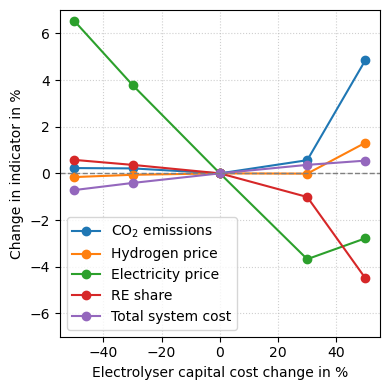

In [328]:
plot_sensitivity("ely", emissions, hydrogen_price, electricity_price, res_share, objective, emissions_comb)

In [277]:
emissions

,power sector
-50_ely,6.430104
-30_ely,6.427787
0_ely,6.392899
30_ely,6.485379
50_ely,7.189527
-50_offshore,6.393058
-30_offshore,6.392899
0_offshore,6.392899
30_offshore,6.392959
50_offshore,6.392899


### Misc

In [278]:
n_sens0.statistics.capex() #.sum()

component    carrier                                  
StorageUnit  Reservoir & Dam                              0.000000e+00
Store        H2                                           9.453295e+03
             Li ion                                       0.000000e+00
             Oil                                          0.000000e+00
             battery                                      1.878229e+03
                                                              ...     
Generator    residential urban decentral solar thermal    3.476867e+02
             services rural solar thermal                 3.481491e+02
             services urban decentral solar thermal       3.485494e+02
             urban central solar thermal                  3.494188e+02
Line         AC                                           2.275619e+08
Length: 85, dtype: float64

In [279]:
n_sens30.statistics.capex() #.sum()

component    carrier                                  
StorageUnit  Reservoir & Dam                              0.000000e+00
Store        H2                                           1.353804e+04
             Li ion                                       0.000000e+00
             Oil                                          0.000000e+00
             battery                                      2.730436e+03
                                                              ...     
Generator    residential urban decentral solar thermal    5.840901e+02
             services rural solar thermal                 5.771640e+02
             services urban decentral solar thermal       6.259248e+02
             urban central solar thermal                  6.630342e+02
Line         AC                                           2.274533e+08
Length: 85, dtype: float64

In [280]:
threshold = 1e5
diff = n_sens30.statistics.capex() - n_sens0.statistics.capex()
diff[(diff < -threshold) | (diff > threshold)] / 1e6

component  carrier        
Link       H2 Electrolysis    11.112753
Generator  Onshore Wind      -11.072802
Line       AC                 -0.108594
dtype: float64

#### Installed capacity in GW

In [281]:
threshold = 1e2
diff = n_sens30.statistics.optimal_capacity() - n_sens0.statistics.optimal_capacity()
(diff[(diff < -threshold) | (diff > threshold)] / 1e3).round(1)

component  carrier        
Store      H2                   80215.2
           co2                    -13.7
           gas                1118167.4
Link       H2                      -0.2
           H2 Electrolysis         -0.4
Generator  Onshore Wind            -0.1
           gas                     -0.1
dtype: float64

In [282]:
n_sens0.statistics.optimal_capacity().loc[:, "H2 Electrolysis"] / 1e3

component
Link    2.62629
dtype: float64

In [283]:
n_sens30.statistics.optimal_capacity().loc[:, "H2 Electrolysis"] / 1e3

component
Link    2.270364
dtype: float64

#### Dispatch in TWh

In [284]:
threshold = 1e5
diff = n_sens30.statistics.dispatch() - n_sens0.statistics.dispatch()
diff[(diff < -threshold) | (diff > threshold)] / 1e6

component  carrier           
Generator  Coal                 -0.187953
           Combined-Cycle Gas    0.829882
           Onshore Wind         -0.559612
dtype: float64

#### RE share

In [285]:
n_regular.generators.loc[n_regular.generators.carrier == "offwind-ac", "capital_cost"] 
#= n_regular.generators.loc[n.generators.carrier == "offshore", "capital_cost"] * 1.3

Generator
NZ.18_1_AC offwind-ac    215930.494633
Name: capital_cost, dtype: float64

In [286]:
n_regular.generators.carrier.unique()

array(['geothermal', 'onwind', 'solar', 'ror', 'CCGT', 'OCGT', 'coal',
       'offwind-ac', 'offwind-dc', 'oil', 'gas',
       'residential rural solar thermal', 'services rural solar thermal',
       'residential urban decentral solar thermal',
       'services urban decentral solar thermal',
       'urban central solar thermal'], dtype=object)

In [287]:
n_regular.statistics.optimal_capacity(comps=["Store"]) / 1e6

component  carrier                                
Store      H2                                         2.794639e+02
           Li ion                                     9.140750e-03
           Oil                                        1.499952e+03
           battery                                    2.689711e-07
           biogas                                     5.000000e-01
           co2                                        3.593134e+01
           co2 stored                                 1.123342e-04
           gas                                        4.276079e+03
           residential rural water tanks              6.861565e-08
           residential urban decentral water tanks    6.945780e-08
           services rural water tanks                 6.866298e-08
           services urban decentral water tanks       6.908426e-08
           solid biomass                              4.000000e+01
           urban central water tanks                  5.302552e-06
Name: e_nom

In [288]:
n_regular.stores.loc[n_regular.stores.carrier == "H2", "capital_cost"]

Store
NZ.11_1_AC H2 Store Tank    3428.802087
NZ.12_1_AC H2 Store Tank    3428.802087
NZ.14_1_AC H2 Store Tank    3428.802087
NZ.15_1_AC H2 Store Tank    3428.802087
NZ.16_1_AC H2 Store Tank    3428.802087
NZ.17_1_AC H2 Store Tank    3428.802087
NZ.18_1_AC H2 Store Tank    3428.802087
NZ.19_1_AC H2 Store Tank    3428.802087
NZ.1_1_AC H2 Store Tank     3428.802087
NZ.2_1_AC H2 Store Tank     3428.802087
NZ.3_1_AC H2 Store Tank     3428.802087
NZ.6_1_AC H2 Store Tank     3428.802087
NZ.7_1_AC H2 Store Tank     3428.802087
NZ.8_1_AC H2 Store Tank     3428.802087
NZ.9_1_AC H2 Store Tank     3428.802087
H2 export store                0.000000
Name: capital_cost, dtype: float64

In [289]:
n_regular.stores.loc["H2 export store"]

bus                           H2 export bus
capital_cost                            0.0
carrier                                  H2
e_cyclic                               True
e_initial                               0.0
e_min_pu                                0.0
e_nom                                   0.0
e_nom_extendable                       True
lifetime                                inf
marginal_cost                       0.00977
standing_loss                           0.0
e_nom_opt                  279463918.339485
type                                       
e_nom_mod                               0.0
e_nom_min                               0.0
e_nom_max                               inf
e_max_pu                                1.0
e_initial_per_period                  False
e_cyclic_per_period                    True
p_set                                   0.0
q_set                                   0.0
sign                                    1.0
marginal_cost_quadratic         

In [290]:
n_regular.stores.loc[n_regular.stores.carrier == "H2"].e_nom_opt

Store
NZ.11_1_AC H2 Store Tank    8.235610e-02
NZ.12_1_AC H2 Store Tank    7.261010e-01
NZ.14_1_AC H2 Store Tank    7.247514e-01
NZ.15_1_AC H2 Store Tank    3.056205e-01
NZ.16_1_AC H2 Store Tank    5.623657e-02
NZ.17_1_AC H2 Store Tank    1.004006e-01
NZ.18_1_AC H2 Store Tank    7.937347e-02
NZ.19_1_AC H2 Store Tank    7.048095e-02
NZ.1_1_AC H2 Store Tank     5.622942e-02
NZ.2_1_AC H2 Store Tank     1.541608e-01
NZ.3_1_AC H2 Store Tank     1.423605e-01
NZ.6_1_AC H2 Store Tank     3.582044e-01
NZ.7_1_AC H2 Store Tank     1.925871e-01
NZ.8_1_AC H2 Store Tank     4.807561e-02
NZ.9_1_AC H2 Store Tank     5.376308e-02
H2 export store             2.794639e+08
Name: e_nom_opt, dtype: float64

In [291]:
n_regular.stores.loc["H2 export store", "capital_cost"]

0.0

In [292]:
idx = n_regular.stores.loc[n_regular.stores.carrier == "H2"].index
idx = idx[idx != "H2 export store"]


n_regular.stores.loc["H2 export store", "capital_cost"] = n_regular.stores.loc[idx].capital_cost.mean()